#1 - Imports and Path Setup

In [1]:
import os
import sys
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib

In [2]:
PROJECT_ROOT = '/content/drive/MyDrive/Transformer_Mine'
FIGURES_DIR  = os.path.join(PROJECT_ROOT, 'figures')


In [85]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/Transformer_Mine

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Transformer_Mine


In [86]:
from data_pipeline import (
    create_padding_mask,
    create_look_ahead_mask,
    create_decoder_mask,
)

In [5]:
os.makedirs(FIGURES_DIR, exist_ok=True)

# 2 - Mathematical Foundation

This cell documents the exact mathematical formulation of the **Scaled Dot-Product Attention** mechanism that we are implementing.

> **Reference:** *Attention Is All You Need*, Section 3.2.1

---

## 1. Core Attention Formula

The attention mechanism is defined as:

$$
\mathrm{Attention}(Q, K, V)
=
\mathrm{softmax}
\left(
\frac{QK^T}{\sqrt{d_k}}
\right)V
$$

Where:

| Symbol | Meaning | Shape |
|---|---|---|
| $Q$ | Query matrix | `(batch, heads, seq_q, d_k)` |
| $K$ | Key matrix | `(batch, heads, seq_k, d_k)` |
| $V$ | Value matrix | `(batch, heads, seq_k, d_v)` |
| $d_k$ | Dimension of keys/queries | $64$ |
| $d_v$ | Dimension of values | $64$ |

For the **Transformer Base** configuration:

$$
d_k = d_v =
\frac{d_{\text{model}}}{\text{num\_heads}}
=
\frac{512}{8}
=
64
$$

---

# 2. Step-by-Step Computation

## Step 1 — Dot Product Scores

First, we calculate the similarity between every query and every key:

$$
\text{scores} = QK^T
$$

### Shape

$$
(batch,\ heads,\ seq_q,\ d_k)
\times
(batch,\ heads,\ d_k,\ seq_k)
$$

produces:

$$
(batch,\ heads,\ seq_q,\ seq_k)
$$

Each value:

$$
\text{scores}_{i,j}
=
Q_i \cdot K_j
$$

measures how strongly **query position $i$** attends to **key position $j$**.

---

## Step 2 — Scaling

The dot-product scores are divided by $\sqrt{d_k}$:

$$
\text{scores}
=
\frac{QK^T}{\sqrt{d_k}}
$$

### Why do we scale?

Without scaling, the magnitude of the dot products tends to increase as $d_k$ increases.

Large values entering the softmax can push it into regions where:

- One or a few positions receive almost all the probability.
- Other positions receive values close to zero.
- Gradients become extremely small.
- Training can become less stable.

Dividing by:

$$
\sqrt{d_k}
$$

helps control the magnitude of the scores and keeps their variance approximately independent of $d_k$.

---

## Step 3 — Masking *(Optional)*

A mask can be applied before the softmax:

$$
\text{scores}
=
\text{scores}
+
\text{mask} \times (-10^9)
$$

Where:

- `mask = 0` → position is allowed.
- `mask = 1` → position should be ignored.

For a masked position:

$$
\text{score} + (-10^9)
\approx -10^9
$$

After applying softmax:

$$
\mathrm{softmax}(-10^9) \approx 0
$$

Therefore, the model effectively assigns **zero attention weight** to masked positions.

> **Note:** In practice, implementations may use a different large negative value or negative infinity rather than exactly $-10^9$.

---

## Step 4 — Softmax

Next, we convert the scaled scores into attention weights:

$$
\text{weights}
=
\mathrm{softmax}(\text{scores},\ axis=-1)
$$

### Shape

$$
(batch,\ heads,\ seq_q,\ seq_k)
$$

The softmax is applied across the **key positions**.

For each query position, the resulting weights form a probability distribution:

$$
\sum_{j=1}^{seq_k}
\text{weights}_{i,j}
=
1
$$

Therefore:

$$
0 \leq \text{weights}_{i,j} \leq 1
$$

The attention weights determine **how much each key/value position contributes** to the current query position.

---

## Step 5 — Weighted Sum of Values

Finally, the attention weights are multiplied by the value matrix:

$$
\text{output}
=
\text{weights} \cdot V
$$

### Shape

$$
(batch,\ heads,\ seq_q,\ seq_k)
\times
(batch,\ heads,\ seq_k,\ d_v)
$$

produces:

$$
(batch,\ heads,\ seq_q,\ d_v)
$$

Each output vector is therefore a **weighted combination of the value vectors**.

The weights are determined by the similarity between queries and keys.

---

# 3. Complete Pipeline

The entire computation can be summarized as:

$$
Q,K,V
$$

$$
\downarrow
$$

$$
QK^T
$$

$$
\downarrow
$$

$$
\frac{QK^T}{\sqrt{d_k}}
$$

$$
\downarrow
$$

$$
\text{Mask (optional)}
$$

$$
\downarrow
$$

$$
\mathrm{softmax}
$$

$$
\downarrow
$$

$$
\text{Attention Weights}
$$

$$
\downarrow
$$

$$
\text{Attention Weights} \times V
$$

$$
\downarrow
$$

$$
\boxed{\text{Attention Output}}
$$

---

# 4. Transformer Base Configuration

The original **Transformer Base** configuration from *Attention Is All You Need* uses:

| Parameter | Value |
|---|---:|
| $d_{\text{model}}$ | $512$ |
| Number of heads | $8$ |
| $d_k$ | $64$ |
| $d_v$ | $64$ |

Since each attention head operates on a portion of the model representation:

$$
d_k = d_v =
\frac{d_{\text{model}}}{\text{num\_heads}}
$$

Therefore:

$$
d_k = d_v =
\frac{512}{8}
=
64
$$

---

## 5. Final Formula

Combining all the steps gives the complete **Scaled Dot-Product Attention** equation:

$$
\boxed{
\mathrm{Attention}(Q,K,V)
=
\mathrm{softmax}
\left(
\frac{QK^T}{\sqrt{d_k}}
\right)V
}
$$

This is the mathematical operation that our implementation will reproduce.

In [7]:
d_model = 512
num_heads = 8
d_k = d_model // num_heads
d_v = d_model // num_heads

In [8]:
print(f"d_model= {d_model}")
print(f"num_heads = {num_heads}")
print(f"d_k= d_model / num_heads = {d_model} / {num_heads} = {d_k}")
print(f"d_v= d_model / num_heads = {d_model} / {num_heads} = {d_v}")
print()
print("Attention output shape:")
print(f"(batch, num_heads, seq_len, d_v)")
print(f"= (batch, {num_heads}, seq_len, {d_v})")
print()
print("After concatenating heads:")
print(f"(batch, seq_len, num_heads * d_v)")
print(f"= (batch, seq_len, {num_heads} * {d_v})")
print(f"= (batch, seq_len, {num_heads * d_v})  ← back to d_model")

d_model= 512
num_heads = 8
d_k= d_model / num_heads = 512 / 8 = 64
d_v= d_model / num_heads = 512 / 8 = 64

Attention output shape:
(batch, num_heads, seq_len, d_v)
= (batch, 8, seq_len, 64)

After concatenating heads:
(batch, seq_len, num_heads * d_v)
= (batch, seq_len, 8 * 64)
= (batch, seq_len, 512)  ← back to d_model


# 3 - Scaled Dot-Product Attention

Implementing the **Scaled Dot-Product Attention** mechanism exactly as defined in the original Transformer paper.

The core equation is:

$$
\mathrm{Attention}(Q,K,V)
=
\mathrm{softmax}
\left(
\frac{QK^T}{\sqrt{d_k}}
\right)V
$$

This is the **core attention function**. It will be called once per attention head inside the `MultiHeadAttention` module in **Phase 5**.

---

## 1. Input Arguments

| Argument | Shape | Description |
|---|---|---|
| $Q$ | `(batch, heads, seq_q, d_k)` | Query matrix |
| $K$ | `(batch, heads, seq_k, d_k)` | Key matrix |
| $V$ | `(batch, heads, seq_k, d_v)` | Value matrix |
| `mask` | `(batch, 1, seq_q, seq_k)` or `(batch, 1, 1, seq_k)` | Attention mask |

### Mask Convention

The mask uses `float32` values:

- `0.0` → position is **not masked**
- `1.0` → position is **masked**

Masked positions will receive a very large negative value before softmax, causing their attention probability to become approximately zero.

---

## 2. Computation

The function performs the following operations:

### Step 1 — Compute $QK^T$

$$
\text{scores} = QK^T
$$

### Step 2 — Scale by $\sqrt{d_k}$

$$
\text{scores}
=
\frac{QK^T}{\sqrt{d_k}}
$$

### Step 3 — Apply the Optional Mask

$$
\text{scores}
=
\text{scores}
+
\text{mask} \times (-10^9)
$$

### Step 4 — Apply Softmax

$$
\text{attention\_weights}
=
\mathrm{softmax}(\text{scores})
$$

### Step 5 — Compute Weighted Sum of Values

$$
\text{output}
=
\text{attention\_weights}V
$$

---

## 3. Output

The function returns two tensors:

| Output | Shape | Description |
|---|---|---|
| `output` | `(batch, heads, seq_q, d_v)` | Final attention representation |
| `attention_weights` | `(batch, heads, seq_q, seq_k)` | Attention probabilities for each query-key pair |

The `attention_weights` tensor is retained because it will be used later for **attention visualisation in Phase 23**.

---

## 4. Complete Data Flow

$$
Q,\ K,\ V
$$

$$
\downarrow
$$

$$
QK^T
$$

$$
\downarrow
$$

$$
\frac{QK^T}{\sqrt{d_k}}
$$

$$
\downarrow
$$

$$
\text{Apply Mask}
$$

$$
\downarrow
$$

$$
\mathrm{softmax}
$$

$$
\downarrow
$$

$$
\text{Attention Weights}
$$

$$
\downarrow
$$

$$
\text{Attention Weights} \times V
$$

$$
\downarrow
$$

$$
\boxed{\text{Output}}
$$

---

## 5. Expected Tensor Shapes

For a typical Transformer configuration:

```text
Q      : (batch, heads, seq_q, d_k)
K      : (batch, heads, seq_k, d_k)
V      : (batch, heads, seq_k, d_v)

Scores :
         (batch, heads, seq_q, seq_k)

Weights:
         (batch, heads, seq_q, seq_k)

Output :
         (batch, heads, seq_q, d_v)

In [115]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k= tf.cast(tf.shape(Q)[-1], tf.float32)
    scores = tf.matmul(Q, K, transpose_b=True)
    scores = scores / tf.math.sqrt(d_k)

    if mask is not None:
        scores = scores + (mask * -1e9)

    attention_weights = tf.nn.softmax(scores, axis=-1)

    output = tf.matmul(attention_weights, V)

    return output, attention_weights


# 4 - Shape Tests

Verify that every tensor shape is exactly correct before  
testing numerical behavior.

We use small artificial tensors — no real data needed here.

In [10]:
batch_size = 2
num_heads = 8
seq_q = 5
seq_k = 7
d_k = 64
d_v = 64

In [11]:
tf.random.set_seed(42)

In [12]:
Q = tf.random.normal(shape = (batch_size, num_heads, seq_q, d_k))
K = tf.random.normal(shape = (batch_size, num_heads, seq_k, d_k))
V = tf.random.normal(shape = (batch_size, num_heads, seq_k, d_v))

In [13]:
Q.shape, K.shape, V.shape

(TensorShape([2, 8, 5, 64]),
 TensorShape([2, 8, 7, 64]),
 TensorShape([2, 8, 7, 64]))

In [14]:
# Test 1: No mask
output, weights = scaled_dot_product_attention(Q, K, V, mask = None)

In [19]:
assert output.shape == (batch_size, num_heads, seq_q, d_v), \
    f"Output shape wrong: {output.shape}"
assert weights.shape == (batch_size, num_heads, seq_q, seq_k), \
    f"Weights shape wrong: {weights.shape}"

In [20]:
output.shape, weights.shape

((2, 8, 5, 64), TensorShape([2, 8, 5, 7]))

In [22]:
# Test 2: With padding mask
padding_mask = tf.constant(
    [[[[0., 0., 0., 0., 0., 1., 1.]]],
     [[[0., 0., 0., 1., 1., 1., 1.]]]]
)

output_with_mask, weights_with_mask = scaled_dot_product_attention(Q, K, V, mask = padding_mask)

In [24]:
output_with_mask.shape, weights_with_mask.shape

((2, 8, 5, 64), TensorShape([2, 8, 5, 7]))

In [27]:
assert output_with_mask.shape== (batch_size, num_heads, seq_q, d_v)
assert weights_with_mask.shape== (batch_size, num_heads, seq_q, seq_k)

In [28]:
# Test 3: Self-attention (seq_q == seq_k)
seq_len = 6
Q_self = tf.random.normal((batch_size, num_heads, seq_len, d_k))
K_self = tf.random.normal((batch_size, num_heads, seq_len, d_k))
V_self = tf.random.normal((batch_size, num_heads, seq_len, d_v))

output_s, weights_s = scaled_dot_product_attention(Q_self, K_self, V_self)

In [29]:
assert output_s.shape  == (batch_size, num_heads, seq_len, d_v)
assert weights_s.shape == (batch_size, num_heads, seq_len, seq_len)


In [30]:
output_s.shape, weights_s.shape

((2, 8, 6, 64), TensorShape([2, 8, 6, 6]))

# CELL 5: Numerical Behavior Tests

Verifies the mathematical properties of the attention output:

1. Attention weights sum to 1.0 across key dim (softmax)
2. Masked positions receive ~0 attention weight
3. Scaling: unscaled attention has higher variance than scaled
4. Identical Q and K → attention concentrates on self
5. Output is a convex combination of V rows

In [31]:
tf.random.set_seed(0)

In [32]:
batch = 2
heads = 4
seq = 5
d_k = 64
d_v = 64

In [34]:
Q = tf.random.normal((batch, heads, seq, d_k))
K = tf.random.normal((batch, heads, seq, d_k))
V = tf.random.normal((batch, heads, seq, d_v))

In [35]:
output, weights = scaled_dot_product_attention(Q, K, V)

## Test 1: Weights sum to 1.0

In [40]:
weight_sums = tf.reduce_sum(weights, axis=-1)

max_deviation = tf.reduce_max(tf.abs(weight_sums - 1.0)).numpy()
# calculates the maximum deviation (error) between the actual sum of attention weights and the expected sum of 1.0.

In [41]:
weight_sums

<tf.Tensor: shape=(2, 4, 5), dtype=float64, numpy=
array([[[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]],

       [[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]]])>

In [42]:
max_deviation

np.float64(2.220446049250313e-16)

This tiny difference is due to floating-point arithmetic precision limits in computer hardware

In [43]:
assert max_deviation < 1e-5, f"Weights don't sum to 1: max dev = {max_deviation}"

##Test 2: Masked positions receive ~0 weight

In [44]:
mask_test = tf.constant([[[[0., 0., 0., 1., 1.]]]])

In [45]:
mask_test.shape

TensorShape([1, 1, 1, 5])

In [46]:
Q_t = tf.random.normal((1, 1, 3, d_k))
K_t = tf.random.normal((1, 1, 5, d_k))
V_t = tf.random.normal((1, 1, 5, d_v))


In [47]:
output_masked, weights_masked = scaled_dot_product_attention(Q_t, K_t, V_t, mask=mask_test)

In [48]:
weights_masked = weights_masked[0,0,:,3:].numpy()

In [49]:
weights_masked

array([[0., 0.],
       [0., 0.],
       [0., 0.]], dtype=float32)

In [50]:
weights_masked.shape

(3, 2)

In [51]:
max_masked_weight = weights_masked.max()

In [52]:
max_masked_weight

np.float32(0.0)

In [53]:
assert max_masked_weight < 1e-7, \
    f"Masked position has non-negligible weight: {max_masked_weight}"

## Test 3: Scaling reduces variance

In [58]:
Q_v = tf.random.normal((1, 1, 10, d_k))
K_v = tf.random.normal((1, 1, 10, d_k))
V_v = tf.random.normal((1, 1, 10, d_v))

# Unscaled scores
scores_unscaled = tf.matmul(Q_v, K_v, transpose_b=True)
var_unscaled = tf.math.reduce_variance(scores_unscaled).numpy()

# Scaled scores
scores_scaled = scores_unscaled / tf.math.sqrt(tf.cast(d_k, tf.float32))
var_scaled= tf.math.reduce_variance(scores_scaled).numpy()


In [59]:
print(f"Variance (unscaled): {var_unscaled:.4f}")
print(f"Variance (scaled): {var_scaled:.4f}")
print(f"Ratio: {var_unscaled / var_scaled:.2f}x "
      f"(expected ~{d_k}x = {d_k})")

Variance (unscaled): 55.8195
Variance (scaled): 0.8722
Ratio: 64.00x (expected ~64x = 64)


In [57]:
assert var_unscaled > var_scaled, "Scaling should reduce variance"

##Test 4: Output is bounded by V

In [62]:
output_v, weights_v = scaled_dot_product_attention(Q_v, K_v, V_v)
v_min = V_v.min() if isinstance(V_v, np.ndarray) else V_v.numpy().min()
v_max = V_v.max() if isinstance(V_v, np.ndarray) else V_v.numpy().max()

o_min = output_v.min()
o_max = output_v.max()

In [65]:
print(f"V range: [{v_min:.4f}, {v_max:.4f}]")
print(f"Out range: [{o_min:.4f}, {o_max:.4f}]")
assert o_min >= v_min - 1e-5 and o_max <= v_max + 1e-5, \
    "Output exceeds V range — not a valid convex combination"

V range: [-3.1555, 3.0509]
Out range: [-1.2939, 1.1566]


# CELL 6: Masking Behavior Tests

Tests both mask types that will be used in the Transformer:

- **A. Padding mask** — certain key positions are PAD tokens
- **B. Causal mask** — decoder cannot attend to future tokens

These tests use the mask functions from Phase 2 to confirm that the masks interact correctly with attention scores.

In [66]:
tf.random.set_seed(1)

##Test A: Padding mask

In [67]:
# Sequence: [token, token, token, PAD, PAD]
# Tokens at positions 3 and 4 are padding.
# Attention should assign 0 weight to positions 3 and 4.

In [68]:
seq_ids = tf.constant([[5, 8, 3, 0, 0]], dtype=tf.int32)

pad_mask = create_padding_mask(seq_ids)

In [69]:
seq_ids.shape, pad_mask.shape

(TensorShape([1, 5]), TensorShape([1, 1, 1, 5]))

In [70]:
Q_p = tf.random.normal((1, 1, 5, 64))
K_p = tf.random.normal((1, 1, 5, 64))
V_p = tf.random.normal((1, 1, 5, 64))

In [71]:
o_pad, w_pad = scaled_dot_product_attention(Q_p, K_p, V_p, mask=pad_mask)

In [72]:
w_pad.shape

TensorShape([1, 1, 5, 5])

In [73]:
print(f"Sequence IDs: {seq_ids[0].numpy()}")
print(f"PAD mask (row 0) : {pad_mask[0,0,0,:].numpy()}")
print(f"Attention weights (query 0 over all keys):")
print(f"{w_pad[0,0,0,:].numpy()}")
print(f"Weight at PAD positions (3,4): "
      f"{w_pad[0,0,0,3].numpy():.2e}, {w_pad[0,0,0,4].numpy():.2e}")

assert w_pad[0,0,0,3].numpy() < 1e-7, "PAD position 3 should have ~0 weight"
assert w_pad[0,0,0,4].numpy() < 1e-7, "PAD position 4 should have ~0 weight"

Sequence IDs: [5 8 3 0 0]
PAD mask (row 0) : [0. 0. 0. 1. 1.]
Attention weights (query 0 over all keys):
[0.1176343  0.78956616 0.09279954 0.         0.        ]
Weight at PAD positions (3,4): 0.00e+00, 0.00e+00


In [74]:
# Non-PAD positions should have non-zero weight summing to 1
non_pad_sum = tf.reduce_sum(w_pad[0,0,0,:3]).numpy()
print(f"Sum of non-PAD weights (positions 0-2): {non_pad_sum:.6f}")
assert abs(non_pad_sum - 1.0) < 1e-5, \
    f"Non-PAD weights should sum to 1, got {non_pad_sum}"

Sum of non-PAD weights (positions 0-2): 1.000000


##Test B: Causal (look-ahead) mask

In [102]:
import importlib
import data_pipeline
importlib.reload(data_pipeline)

from data_pipeline import (
    create_padding_mask,
    create_look_ahead_mask,
    create_decoder_mask,
)

In [ ]:
seq_len  = 6
look_ahead_mask = create_look_ahead_mask(seq_len)

In [104]:
look_ahead_mask.shape

TensorShape([1, 1, 6, 6])

In [105]:
Q_c = tf.random.normal((1, 1, seq_len, 64))
K_c = tf.random.normal((1, 1, seq_len, 64))
V_c = tf.random.normal((1, 1, seq_len, 64))

In [106]:
_, w_causal = scaled_dot_product_attention(Q_c, K_c, V_c, mask=look_ahead_mask)

In [107]:
print(create_look_ahead_mask(seq_len)[0, 0].numpy())

[[0. 1. 1. 1. 1. 1.]
 [0. 0. 1. 1. 1. 1.]
 [0. 0. 0. 1. 1. 1.]
 [0. 0. 0. 0. 1. 1.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0.]]


In [108]:
w_matrix = w_causal[0, 0].numpy()
for row_i, row in enumerate(w_matrix):
    formatted = [f"{v:.3f}" for v in row]
    print(f"    query {row_i}: {formatted}")

# Verify upper triangle is ~0
violations = 0
for i in range(seq_len):
    for j in range(i+1, seq_len):
        if w_matrix[i, j] > 1e-7:
            violations += 1
            print(f"  X Causal violation: query {i} attends to future key {j} "
                  f"with weight {w_matrix[i,j]:.6f}")

if violations == 0:
    print(f"\n  <<W>> Causal mask test passed — no future tokens attended to.")
else:
    print(f"\n  X {violations} causal violations found.")

# Verify diagonal and below are non-zero (can attend to self + past)
for i in range(seq_len):
    assert w_matrix[i, i] > 0, f"Position {i} has zero self-attention weight"

    query 0: ['1.000', '0.000', '0.000', '0.000', '0.000', '0.000']
    query 1: ['0.505', '0.495', '0.000', '0.000', '0.000', '0.000']
    query 2: ['0.267', '0.365', '0.367', '0.000', '0.000', '0.000']
    query 3: ['0.253', '0.021', '0.555', '0.170', '0.000', '0.000']
    query 4: ['0.479', '0.213', '0.039', '0.174', '0.095', '0.000']
    query 5: ['0.094', '0.073', '0.042', '0.296', '0.012', '0.483']

  <<W>> Causal mask test passed — no future tokens attended to.


# CELL 7: Gradient Flow Test

Verifies that gradients flow correctly through the attention  
operation back to Q, K, and V.

If gradients are None or zero, the model cannot learn.

This is a critical check before building larger components.

In [116]:
tf.random.set_seed(42)

In [117]:
batch, heads, seq, dk, dv = 2, 4, 6, 64, 64

In [118]:
Q_var = tf.Variable(tf.random.normal((batch, heads, seq, dk)), trainable=True)
K_var = tf.Variable(tf.random.normal((batch, heads, seq, dk)), trainable=True)
V_var = tf.Variable(tf.random.normal((batch, heads, seq, dv)), trainable=True)

In [119]:
with tf.GradientTape() as tape:
    # Explicitly watch the variables (belt and suspenders)
    tape.watch(Q_var)
    tape.watch(K_var)
    tape.watch(V_var)

    output, weights = scaled_dot_product_attention(Q_var, K_var, V_var)
    loss = tf.reduce_sum(output)

grads = tape.gradient(loss, [Q_var, K_var, V_var])

print(f"Gradient shapes and norms:")
names = ['Q', 'K', 'V']
all_ok = True
for name, var, grad in zip(names, [Q_var, K_var, V_var], grads):
    if grad is None:
        print(f"  {name}: ❌ gradient is None — backprop broken!")
        all_ok = False
    else:
        grad_norm = tf.norm(grad).numpy()
        has_nan   = tf.reduce_any(tf.math.is_nan(grad)).numpy()
        has_inf   = tf.reduce_any(tf.math.is_inf(grad)).numpy()
        status    = "✅" if (grad_norm > 0 and not has_nan and not has_inf) else "❌"
        print(f"  {name}: shape={grad.shape}  "
              f"norm={grad_norm:.4f}  "
              f"nan={has_nan}  inf={has_inf}  {status}")
        if has_nan or has_inf or grad_norm == 0:
            all_ok = False

if all_ok:
    print(f"\n✅ Gradient flow test passed.")
else:
    print(f"\n❌ Gradient flow test FAILED.")

Gradient shapes and norms:
  Q: shape=(2, 4, 6, 64)  norm=20.9355  nan=False  inf=False  ✅
  K: shape=(2, 4, 6, 64)  norm=21.4086  nan=False  inf=False  ✅
  V: shape=(2, 4, 6, 64)  norm=59.1165  nan=False  inf=False  ✅

✅ Gradient flow test passed.


# CELL 8: Attention Visualisation

Creates a heatmap of attention weights for a small example.

This previews what the full attention visualisation (Phase 23)  
will look like on real trained translations.

Using Stage A vocabulary with a short sentence pair.

In [121]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [122]:
from tokenizer import BPETokenizer

In [123]:
VOCAB_DIR_A = os.path.join(PROJECT_ROOT, 'vocab/stage_a')
tokenizer_a = BPETokenizer.load(VOCAB_DIR_A)

In [124]:
src_text = "I am a student ."
tgt_text = "Ich bin ein Student ."

src_ids = tokenizer_a.encode(src_text)
tgt_ids = tokenizer_a.encode(tgt_text)

src_tokens = [tokenizer_a.id2token[i] for i in src_ids]
tgt_tokens = [tokenizer_a.id2token[i] for i in tgt_ids]

seq_q = len(tgt_ids)
seq_k = len(src_ids)

In [125]:
seq_q, seq_k

(6, 6)

In [126]:
tf.random.set_seed(7)
dk_vis = 16
Q_vis = tf.random.normal((1, 1, seq_q, dk_vis))
K_vis = tf.random.normal((1, 1, seq_k, dk_vis))
V_vis = tf.random.normal((1, 1, seq_k, dk_vis))

_, weights_vis = scaled_dot_product_attention(Q_vis, K_vis, V_vis)

In [127]:
attn_matrix = weights_vis[0, 0].numpy()

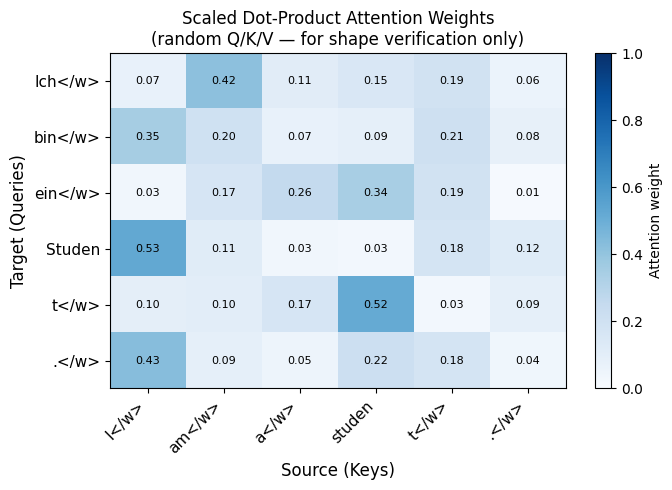

In [128]:
fig, ax = plt.subplots(figsize=(7, 5))

im = ax.imshow(attn_matrix, cmap='Blues', aspect='auto', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Attention weight')

ax.set_xticks(range(seq_k))
ax.set_yticks(range(seq_q))
ax.set_xticklabels(src_tokens, rotation=45, ha='right', fontsize=11)
ax.set_yticklabels(tgt_tokens, fontsize=11)
ax.set_xlabel('Source (Keys)', fontsize=12)
ax.set_ylabel('Target (Queries)', fontsize=12)
ax.set_title('Scaled Dot-Product Attention Weights\n'
             '(random Q/K/V — for shape verification only)', fontsize=12)

# Annotate cells with weight values
for i in range(seq_q):
    for j in range(seq_k):
        ax.text(j, i, f'{attn_matrix[i,j]:.2f}',
                ha='center', va='center', fontsize=8,
                color='black' if attn_matrix[i,j] < 0.6 else 'white')

plt.tight_layout()


In [129]:
fig_path = os.path.join(FIGURES_DIR, 'attention_weights_phase4.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Attention heatmap saved to: {fig_path}")
print(f"   Shape: queries={seq_q} (target), keys={seq_k} (source)")
print(f"   Note: weights are from random Q/K/V — not a trained model.")
print(f"   Real alignment patterns will appear after training (Phase 23).")

<Figure size 640x480 with 0 Axes>


✅ Attention heatmap saved to: /content/drive/MyDrive/Transformer_Mine/figures/attention_weights_phase4.png
   Shape: queries=6 (target), keys=6 (source)
   Note: weights are from random Q/K/V — not a trained model.
   Real alignment patterns will appear after training (Phase 23).


# CELL 9: Causal Mask Visualisation

Plots the look-ahead mask for a sequence of length 8.

This makes the causal structure visually obvious.

In [130]:
seq_len = 8
lm = create_look_ahead_mask(seq_len)
lm_np = lm[0, 0].numpy()

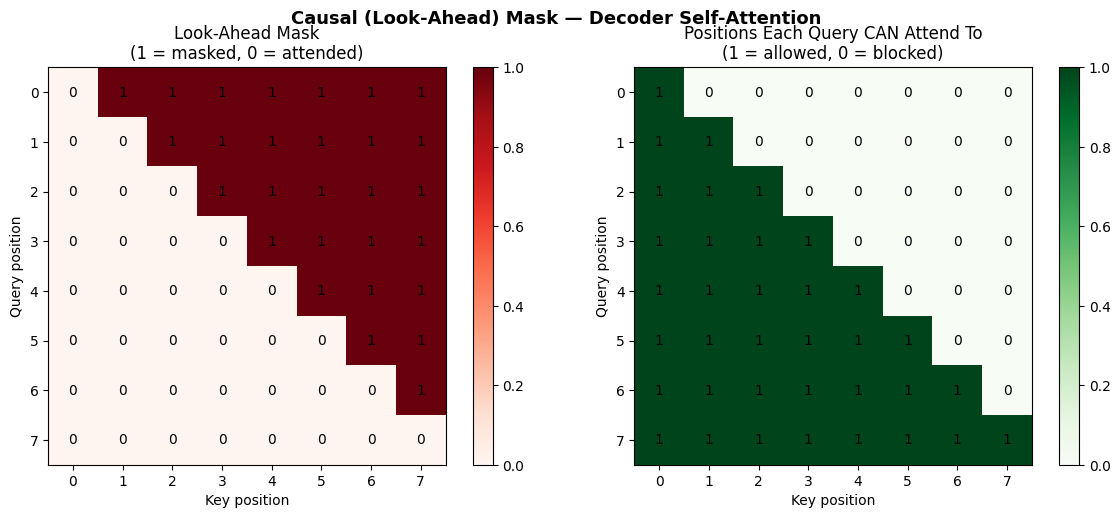

In [132]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# ── Left: raw mask (1 = masked) ──────────────────────────────
ax = axes[0]
im = ax.imshow(lm_np, cmap='Reds', vmin=0, vmax=1)
ax.set_title('Look-Ahead Mask\n(1 = masked, 0 = attended)', fontsize=12)
ax.set_xlabel('Key position')
ax.set_ylabel('Query position')
for i in range(seq_len):
    for j in range(seq_len):
        ax.text(j, i, f'{int(lm_np[i,j])}',
                ha='center', va='center', fontsize=10)
plt.colorbar(im, ax=ax)

# ── Right: what each position CAN attend to ──────────────────
ax2   = axes[1]
can_attend = 1.0 - lm_np   # 1 = can attend, 0 = cannot
im2   = ax2.imshow(can_attend, cmap='Greens', vmin=0, vmax=1)
ax2.set_title('Positions Each Query CAN Attend To\n'
              '(1 = allowed, 0 = blocked)', fontsize=12)
ax2.set_xlabel('Key position')
ax2.set_ylabel('Query position')
for i in range(seq_len):
    for j in range(seq_len):
        ax2.text(j, i, f'{int(can_attend[i,j])}',
                 ha='center', va='center', fontsize=10)
plt.colorbar(im2, ax=ax2)

plt.suptitle('Causal (Look-Ahead) Mask — Decoder Self-Attention',
             fontsize=13, fontweight='bold')
plt.tight_layout()

fig_path = os.path.join(FIGURES_DIR, 'causal_mask_phase4.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

In [133]:
print(f"✅ Causal mask figure saved to: {fig_path}")
print()
print("Reading the left matrix (row = query, col = key):")
print("  Row 0 (first token)  : can only attend to position 0 (itself)")
print("  Row 3 (fourth token) : can attend to positions 0, 1, 2, 3")
print("  Row 7 (last token)   : can attend to all positions 0–7")

✅ Causal mask figure saved to: /content/drive/MyDrive/Transformer_Mine/figures/causal_mask_phase4.png

Reading the left matrix (row = query, col = key):
  Row 0 (first token)  : can only attend to position 0 (itself)
  Row 3 (fourth token) : can attend to positions 0, 1, 2, 3
  Row 7 (last token)   : can attend to all positions 0–7


# CELL 10: Final Integration Check and Save

Saves `scaled_dot_product_attention` to `attention.py` on Drive  
for use in Phase 5 (`MultiHeadAttention`).

In [134]:
ATTENTION_PY = os.path.join(PROJECT_ROOT, 'attention.py')

In [139]:
code = '''"""
attention.py — Scaled Dot-Product Attention

Usage:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd /content/drive/MyDrive/Transformer_Mine
    from attention import scaled_dot_product_attention
"""

import tensorflow as tf

def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Compute scaled dot-product attention.

    Attention(Q, K, V) = softmax(Q @ K^T / sqrt(d_k)) @ V

    Args:
        Q   : (batch, heads, seq_q, d_k)
        K   : (batch, heads, seq_k, d_k)
        V   : (batch, heads, seq_k, d_v)
        mask: float32, broadcastable to (batch, heads, seq_q, seq_k)
              1.0 = masked, 0.0 = attended

    Returns:
        output           : (batch, heads, seq_q, d_v)
        attention_weights: (batch, heads, seq_q, seq_k)
    """
    d_k = tf.cast(tf.shape(Q)[-1], tf.float32)
    scores = tf.matmul(Q, K, transpose_b=True)

    scores = scores / tf.math.sqrt(d_k)

    if mask is not None:
        scores = scores + (mask * -1e9)

    attention_weights = tf.nn.softmax(scores, axis=-1)

    output = tf.matmul(attention_weights, V)

    return output, attention_weights
'''


In [140]:

with open(ATTENTION_PY, 'w', encoding='utf-8') as f:
    f.write(code)


In [141]:
from attention import scaled_dot_product_attention as sdpa_loaded

tf.random.set_seed(0)
Q_f = tf.random.normal((2, 8, 10, 64))
K_f = tf.random.normal((2, 8, 10, 64))
V_f = tf.random.normal((2, 8, 10, 64))

out_f, w_f = sdpa_loaded(Q_f, K_f, V_f)

assert out_f.shape == (2, 8, 10, 64)
assert w_f.shape   == (2, 8, 10, 10)
assert abs(tf.reduce_sum(w_f[0,0,0,:]).numpy() - 1.0) < 1e-5

print("✅ attention.py saved and reloaded successfully.")
print(f"   Path: {ATTENTION_PY}")
print()
print("Final shape verification (Transformer Base dimensions):")
print(f"  Input  — Q/K/V : (2, 8, 10, 64)")
print(f"  Output         : {out_f.shape}  ✅")
print(f"  Weights        : {w_f.shape}  ✅")
print(f"  Weights sum    : {tf.reduce_sum(w_f[0,0,0,:]).numpy():.6f}  ✅")
print()

✅ attention.py saved and reloaded successfully.
   Path: /content/drive/MyDrive/Transformer_Mine/attention.py

Final shape verification (Transformer Base dimensions):
  Input  — Q/K/V : (2, 8, 10, 64)
  Output         : (2, 8, 10, 64)  ✅
  Weights        : (2, 8, 10, 10)  ✅
  Weights sum    : 1.000000  ✅

